In [1]:
# !python3 -m pip install coppeliasim-zmqremoteapi-client
# !pip install torch scikit-learn

In [2]:
from coppeliasim_zmqremoteapi_client import RemoteAPIClient
import time
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import os
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

### Подключение к CoppeliaSim и дополнительные настройки

In [3]:
# Подключение к симулятору
client = RemoteAPIClient('127.0.0.1', 23000)
sim = client.require('sim')

# Описание суставов модели
joint_names = [
    'Revolute_Head_Spine_1', 'Revolute_Spine_1_2', 'Revolute_Spine_2_3',
    'Revolute_Spine_3_4', 'Revolute_Spine_4_LHip', 'Revolute_LH_LBL',
    'Revolute_Spine_4_RHip', 'Revolute_RH_RBL', 'Revolute_Spine_1_RForearm',
    'Revolute_RF_RFL', 'Revolute_Spine_1_LForearm', 'Revolute_LF_LFL',
]

# Идентификаторы суставов
joint_handles = {name: sim.getObjectHandle(name) for name in joint_names}
# Корневой объект модели
main_handle = sim.getObjectHandle('Spine_1')

# Амплитуда колебания каждого сустава в радианах относительно позиции покоя
joint_amp = {
    'Revolute_Head_Spine_1': 0.00,
    'Revolute_Spine_1_2': 0.00,
    'Revolute_Spine_2_3': 0.00,
    'Revolute_Spine_3_4': 0.00,
    'Revolute_Spine_4_LHip': -0.45,
    'Revolute_LH_LBL': 0.00,
    'Revolute_Spine_4_RHip': -0.45,
    'Revolute_RH_RBL': 0.00,
    'Revolute_Spine_1_LForearm': -0.45,
    'Revolute_LF_LFL': 0.00,
    'Revolute_Spine_1_RForearm':-0.45,
    'Revolute_RF_RFL': 0.00
}

# Фазовый сдвиг каждого сустава в радианах (pi - противофаза, 0 - фаза)
joint_phase = {
    'Revolute_Head_Spine_1': 0.00,
    'Revolute_Spine_1_2': 0.00,
    'Revolute_Spine_2_3': 0.00,
    'Revolute_Spine_3_4': 0.00,
    'Revolute_Spine_4_LHip': np.pi,
    'Revolute_LH_LBL': 0.00,
    'Revolute_Spine_4_RHip': 0.00,
    'Revolute_RH_RBL': 0.00,
    'Revolute_Spine_1_LForearm': 0.00,
    'Revolute_LF_LFL': 0.00,
    'Revolute_Spine_1_RForearm': np.pi,
    'Revolute_RF_RFL': 0.00
}

# Ограничения углов поворота в радианах
joint_limits = {
    'Revolute_Head_Spine_1': (0.0, 0.0),
    'Revolute_Spine_1_2': (0.0, 0.0),
    'Revolute_Spine_2_3': (0.0, 0.0),
    'Revolute_Spine_3_4': (0.0, 0.0),
    'Revolute_Spine_4_LHip': (-1.2, 1.2),
    'Revolute_LH_LBL': (0.0, 0.0),
    'Revolute_Spine_4_RHip': (-1.2, 1.2),
    'Revolute_RH_RBL': (0.0, 0.0),
    'Revolute_Spine_1_LForearm': (-1.2, 1.2),
    'Revolute_LF_LFL': (0.0, 0.0),
    'Revolute_Spine_1_RForearm': (-1.2, 1.2),
    'Revolute_RF_RFL': (0.0, 0.0)
}

gait_freq = 1.0 # гц
step_length = 0.01 # м
step_dt = 0.05 # с
seq_len = 10 # длина окна для LSTM

# Позиции покоя суставов (на момент запуска)
joint_rest = {
    name: float(sim.getJointPosition(joint_handles[name]))
    for name in joint_names
}

### Вспомогательные функции

In [4]:
# Вектор суставов для момента t
def sinusoidal_targets(t: float) -> np.ndarray:
    out = np.zeros(len(joint_names))
    for i, name in enumerate(joint_names):
        out[i] = (joint_rest[name] + joint_amp[name] * np.sin(2 * np.pi * gait_freq * t + joint_phase[name]))
    return out

# Входной вектор для нейросети (углы каждого сустава + sin/cos фазы цикла)
def get_state_with_phase(t: float) -> np.ndarray:
    positions = np.array([
        float(sim.getJointPosition(joint_handles[n])) for n in joint_names
    ])
    phase = 2 * np.pi * gait_freq * t
    return np.concatenate([positions, [np.sin(phase), np.cos(phase)]])

# Защита от ошибки CBOR
def set_joint(name: str, value: float) -> None:
    sim.setJointTargetPosition(joint_handles[name], float(value))

# Применение вектора целевых углов ко всем суставам
def apply_targets(targets: np.ndarray) -> None:
    for i, name in enumerate(joint_names):
        low, high = joint_limits[name]
        set_joint(name, float(np.clip(targets[i], low, high)))

# Перемещение модели (только по оси X)
def set_object_position(offset: float, base_pos: list) -> None:
    sim.setObjectPosition(
        main_handle, -1,
        [float(base_pos[0] + offset), float(base_pos[1]), float(base_pos[2])]
    )

### Ходьба без нейросети

In [5]:
# Скрипт ходьбы без применения нейросети
def walk(n_steps: int = 100):
    sim.startSimulation()
    pos = sim.getObjectPosition(main_handle)
    forward_offset = 0.0
    t = 0.0

    for _ in range(n_steps):
        apply_targets(sinusoidal_targets(t))
        time.sleep(step_dt)
        forward_offset += step_length
        set_object_position(forward_offset, pos)
        t += step_dt

### Сбор данных для обучения

In [6]:
# Используется для обучения WalkingNet и CPGNet. Файл: walking_data.pkl
def walk_with_data_collection(n_steps: int = 800):
    global data_buffer
    data_buffer = []
    sim.startSimulation()
    pos = sim.getObjectPosition(main_handle)
    forward_offset = 0.0
    t = 0.0

    for step in range(n_steps):
        data_buffer.append({
            'input':  get_state_with_phase(t),
            'output': sinusoidal_targets(t + step_dt),
        })
        apply_targets(sinusoidal_targets(t))
        time.sleep(step_dt)
        forward_offset += step_length
        set_object_position(forward_offset, pos)
        t += step_dt
    
    # Запись
    with open('walking_data.pkl', 'wb') as f:
        pickle.dump(data_buffer, f)
    # Чтение
    with open('walking_data.pkl', 'rb') as f:
        data_r = pickle.load(f)
    print(data_r)

# Используется для обучения LSTM. Файл: walking_data_lstm.pkl
def walk_with_data_collection_lstm(n_steps: int = 800):
    global data_buffer
    data_buffer = []
    history = []

    sim.startSimulation()

    pos = sim.getObjectPosition(main_handle)
    forward_offset = 0.0
    t = 0.0

    for step in range(n_steps):
        current = np.array([
            float(sim.getJointPosition(joint_handles[n])) for n in joint_names
        ])
        history.append(current)

        if len(history) >= seq_len:
            data_buffer.append({
                'input':  np.stack(history[-seq_len:], axis=0),
                'output': sinusoidal_targets(t + step_dt),
            })

        apply_targets(sinusoidal_targets(t))
        time.sleep(step_dt)
        forward_offset += step_length
        set_object_position(forward_offset, pos)
        t += step_dt

    # Запись
    with open('walking_data_lstm.pkl', 'wb') as f:
        pickle.dump(data_buffer, f)
    # Чтение
    with open('walking_data_lstm.pkl', 'rb') as f:
        data_r = pickle.load(f)
    print(data_r)

### Архитектуры нейронных сетей

In [ ]:
# WalkingNet - полносвязная сеть
class WalkingNet(nn.Module):
    def __init__(self, input_size: int = 14, output_size: int = 12):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, 128), nn.Tanh(),
            nn.Linear(128, output_size)
        )

    def forward(self, x):
        return self.net(x)


# WalkingLSTM - рекуррентная сеть
class WalkingLSTM(nn.Module):
    def __init__(self, input_size: int = 12, hidden_size: int = 128, num_layers: int = 2, output_size: int = 12):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.1)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64), nn.Tanh(),
            nn.Linear(64, output_size)
        )

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        return self.head(out[:, -1, :]), hidden


# CPGNet - сеть с центральным паттерн-генератором
class CPGNet(nn.Module):
    def __init__(self, state_size: int = 14, output_size: int = 12, correction_scale: float = 0.3):
        super().__init__()
        self.correction_scale = correction_scale
        self.corrector = nn.Sequential(
            nn.Linear(state_size, 128), nn.Tanh(),
            nn.Linear(128, 64), nn.Tanh(),
            nn.Linear(64, output_size),
            nn.Tanh()
        )

    def forward(self, state, cpg_target):
        return cpg_target + self.corrector(state) * self.correction_scale

### Обучение

In [8]:
# Загрузка walking_data.pkl
def _load_flat_data(pkl_file: str):
    data = pickle.load(open(pkl_file, 'rb'))
    inputs = torch.tensor(np.stack([d['input']  for d in data]), dtype=torch.float32)
    targets = torch.tensor(np.stack([d['output'] for d in data]), dtype=torch.float32)
    mean = inputs.mean(dim=0)
    std = inputs.std(dim=0).clamp(min=1e-6)
    return inputs, targets, mean, std


def _train_loop(model, loader, epochs, lr, dataset_len, label):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    history = []

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch in loader:
            xb = batch[0]
            yb = batch[-1]
            optimizer.zero_grad()

            if isinstance(model, WalkingLSTM):
                pred, _ = model(xb)
            elif isinstance(model, CPGNet):
                cpg_b = batch[1]
                pred = model(xb, cpg_b)
            else:
                pred = model(xb)

            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(xb)

        scheduler.step()
        avg = epoch_loss / dataset_len
        history.append(avg)
        if epoch % 200 == 0:
            print(f"[{label}] Epoch {epoch:4d}  loss={avg:.6f}"
                  f"  lr={scheduler.get_last_lr()[0]:.2e}")

    return history


def train_walkingnet(epochs: int = 2000, batch_size: int = 64, lr: float = 3e-4):
    if not os.path.exists('walking_data.pkl'):
        print("Нет walking_data.pkl. Запустите walk_with_data_collection.")
        return
    inputs, targets, mean, std = _load_flat_data('walking_data.pkl')
    inputs_n = (inputs - mean) / std
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(inputs_n, targets),
        batch_size=batch_size, shuffle=True)
    model = WalkingNet()
    history = _train_loop(model, loader, epochs, lr, len(inputs), 'WalkingNet')
    torch.save({'model': model.state_dict(), 'input_mean': mean, 'input_std': std, 'loss_history': history}, 'walking_model.pth')
    print("Сохранено в walking_model.pth")
    return model, history

def train_lstm(epochs: int = 2000, batch_size: int = 64, lr: float = 3e-4):
    if not os.path.exists('walking_data_lstm.pkl'):
        print("Нет walking_data_lstm.pkl. Запустите walk_with_data_collection_lstm.")
        return
    data = pickle.load(open('walking_data_lstm.pkl', 'rb'))
    inputs = torch.tensor(np.stack([d['input']  for d in data]), dtype=torch.float32)
    targets = torch.tensor(np.stack([d['output'] for d in data]), dtype=torch.float32)

    flat = inputs.reshape(-1, inputs.shape[-1])
    mean = flat.mean(dim=0)
    std = flat.std(dim=0).clamp(min=1e-6)
    inputs_n = (inputs - mean) / std

    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(inputs_n, targets),
        batch_size=batch_size, shuffle=True)
    model = WalkingLSTM()
    history = _train_loop(model, loader, epochs, lr, len(inputs), 'LSTM')
    torch.save({'model': model.state_dict(), 'input_mean': mean, 'input_std': std, 'loss_history': history}, 'walking_lstm.pth')
    print("Сохранено в walking_lstm.pth")
    return model, history

def train_cpg(epochs: int = 1500, batch_size: int = 64, lr: float = 3e-4):
    if not os.path.exists('walking_data.pkl'):
        print("Нет walking_data.pkl. Запустите walk_with_data_collection.")
        return
    inputs, targets, mean, std = _load_flat_data('walking_data.pkl')
    inputs_n = (inputs - mean) / std

    phases = torch.atan2(inputs[:, -2], inputs[:, -1])
    ts = (phases / (2 * np.pi * gait_freq)).numpy()
    cpg_basis = torch.tensor(np.stack([sinusoidal_targets(float(t)) for t in ts]), dtype=torch.float32)

    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(inputs_n, cpg_basis, targets),
        batch_size=batch_size, shuffle=True)
    model = CPGNet()
    history = _train_loop(model, loader, epochs, lr, len(inputs), 'CPGNet')
    torch.save({'model': model.state_dict(), 'input_mean': mean, 'input_std': std, 'loss_history': history}, 'walking_cpg.pth')
    print("Сохранено в walking_cpg.pth")
    return model, history

def train_all():
    # Обучает все три сети
    print("═" * 60)
    print("1/3  WalkingNet")
    print("═" * 60)
    train_walkingnet()
    print("\n" + "═" * 60)
    print("2/3  LSTM")
    print("═" * 60)
    train_lstm()
    print("\n" + "═" * 60)
    print("3/3  CPGNet")
    print("═" * 60)
    train_cpg()

### Ходьба с применением нейросетей

In [9]:
# Ходьба с WalkingNet
def walk_with_wn(n_steps: int = 40):
    if not os.path.exists('walking_model.pth'):
        print("Нет walking_model.pth. Запустите train_walkingnet.")
        return
    ckpt = torch.load('walking_model.pth', weights_only=True)
    mean = ckpt['input_mean']
    std = ckpt['input_std']
    model = WalkingNet()
    model.load_state_dict(ckpt['model'])
    model.eval()

    sim.startSimulation()
    pos = sim.getObjectPosition(main_handle)
    forward_offset, t = 0.0, 0.0
    try:
        for step in range(n_steps):
            state = torch.tensor(get_state_with_phase(t), dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                pred = model((state - mean) / std).numpy().flatten()
            apply_targets(pred)
            time.sleep(step_dt)
            forward_offset += step_length
            set_object_position(forward_offset, pos)
            t += step_dt
    except Exception as e:
        print(f"Ошибка: {e}")
    finally:
        sim.stopSimulation()
        print("Ходьба завершена.")

# Ходьба с LSTM
def walk_with_lstm(n_steps: int = 40):
    if not os.path.exists('walking_lstm.pth'):
        print("Нет walking_lstm.pth. Запустите train_lstm.")
        return
    ckpt = torch.load('walking_lstm.pth', weights_only=True)
    mean = ckpt['input_mean']
    std = ckpt['input_std']
    model = WalkingLSTM()
    model.load_state_dict(ckpt['model'])
    model.eval()

    sim.startSimulation()
    pos = sim.getObjectPosition(main_handle)
    forward_offset, t = 0.0, 0.0
    history, hidden = [], None
    try:
        for step in range(n_steps):
            current = np.array([
                float(sim.getJointPosition(joint_handles[n])) for n in joint_names
            ])
            history.append(current)

            if len(history) < seq_len:
                apply_targets(sinusoidal_targets(t))
            else:
                seq  = np.stack(history[-seq_len:], axis=0)
                inp  = torch.tensor(seq, dtype=torch.float32).unsqueeze(0)
                inp  = (inp - mean) / std
                with torch.no_grad():
                    pred, hidden = model(inp, hidden)
                apply_targets(pred.numpy().flatten())

            time.sleep(step_dt)
            forward_offset += step_length
            set_object_position(forward_offset, pos)
            t += step_dt
    except Exception as e:
        print(f"Ошибка: {e}")
    finally:
        sim.stopSimulation()
        print("Ходьба завершена.")

# Ходьба с CPGNet
def walk_with_cpg(n_steps: int = 40):
    if not os.path.exists('walking_cpg.pth'):
        print("Нет walking_cpg.pth. Запустите train_cpg.")
        return
    ckpt = torch.load('walking_cpg.pth', weights_only=True)
    mean = ckpt['input_mean']
    std = ckpt['input_std']
    model = CPGNet()
    model.load_state_dict(ckpt['model'])
    model.eval()

    sim.startSimulation()
    pos = sim.getObjectPosition(main_handle)
    forward_offset, t = 0.0, 0.0
    try:
        for step in range(n_steps):
            state = torch.tensor(get_state_with_phase(t), dtype=torch.float32).unsqueeze(0)
            cpg_tgt = torch.tensor(sinusoidal_targets(t), dtype=torch.float32).unsqueeze(0)
            state_n = (state - mean) / std
            with torch.no_grad():
                pred = model(state_n, cpg_tgt).numpy().flatten()
            apply_targets(pred)
            time.sleep(step_dt)
            forward_offset += step_length
            set_object_position(forward_offset, pos)
            t += step_dt
    except Exception as e:
        print(f"Ошибка: {e}")
    finally:
        sim.stopSimulation()
        print("Ходьба завершена.")

### Сравнение моделей

1. Сравнение WalkingNet, LSTM и CPGNet по трём метрикам на одних данных:
- MAE - средняя абсолютная ошибка (рад), цель < 0.05
- MaxErr - максимальная ошибка по любому суставу (рад), цель < 0.15
- R2 - коэффициент детерминации, цель > 0.95

2. Выстраивание графика кривых loss всех моделей

In [ ]:
def compare_models():
    if not os.path.exists('walking_data.pkl'):
        print("Нет walking_data.pkl.")
        return

    data = pickle.load(open('walking_data.pkl', 'rb'))
    inputs = np.stack([d['input']  for d in data])
    targets = np.stack([d['output'] for d in data])
    inp_t = torch.tensor(inputs, dtype=torch.float32)

    results = {}
    loss_curves = {}

    # WalkingNet
    if os.path.exists('walking_model.pth'):
        ckpt  = torch.load('walking_model.pth', weights_only=True)
        mean, std = ckpt['input_mean'], ckpt['input_std']
        net   = WalkingNet(); net.load_state_dict(ckpt['model']); net.eval()
        with torch.no_grad():
            pred = net((inp_t - mean) / std).numpy()
        results['WalkingNet'] = {
            'MAE': float(np.abs(pred - targets).mean()),
            'MaxErr': float(np.abs(pred - targets).max()),
            'R2': float(r2_score(targets, pred)),
        }
        if 'loss_history' in ckpt:
            loss_curves['WalkingNet'] = ckpt['loss_history']
    else:
        print("walking_model.pth не найден, пропускаем WalkingNet")

    # CPGNet
    if os.path.exists('walking_cpg.pth'):
        ckpt = torch.load('walking_cpg.pth', weights_only=True)
        mean, std = ckpt['input_mean'], ckpt['input_std']
        net = CPGNet(); net.load_state_dict(ckpt['model']); net.eval()
        phases = np.arctan2(inputs[:, -2], inputs[:, -1])
        ts = phases / (2 * np.pi * gait_freq)
        cpg_basis = torch.tensor(np.stack([sinusoidal_targets(float(t)) for t in ts]), dtype=torch.float32)
        with torch.no_grad():
            pred = net((inp_t - mean) / std, cpg_basis).numpy()
        results['CPGNet'] = {
            'MAE': float(np.abs(pred - targets).mean()),
            'MaxErr': float(np.abs(pred - targets).max()),
            'R2': float(r2_score(targets, pred)),
        }
        if 'loss_history' in ckpt:
            loss_curves['CPGNet'] = ckpt['loss_history']
    else:
        print("walking_cpg.pth не найден, пропускаем CPGNet")

    # LSTM
    if os.path.exists('walking_lstm.pth') and os.path.exists('walking_data_lstm.pkl'):
        ckpt = torch.load('walking_lstm.pth', weights_only=True)
        mean, std = ckpt['input_mean'], ckpt['input_std']
        net = WalkingLSTM(); net.load_state_dict(ckpt['model']); net.eval()
        lstm_data = pickle.load(open('walking_data_lstm.pkl', 'rb'))
        lstm_inputs = torch.tensor(np.stack([d['input'] for d in lstm_data]), dtype=torch.float32)
        lstm_tgts = np.stack([d['output'] for d in lstm_data])
        lstm_n = (lstm_inputs - mean) / std
        with torch.no_grad():
            pred, _ = net(lstm_n)
        pred = pred.numpy()
        results['LSTM'] = {
            'MAE': float(np.abs(pred - lstm_tgts).mean()),
            'MaxErr': float(np.abs(pred - lstm_tgts).max()),
            'R2': float(r2_score(lstm_tgts, pred)),
        }
        if 'loss_history' in ckpt:
            loss_curves['LSTM'] = ckpt['loss_history']
    else:
        print("walking_lstm.pth и walking_data_lstm.pkl не найдены, пропускаем LSTM")

    if not results:
        print("Нет обученных моделей для сравнения")
        return

    # Таблица метрик
    print(f"\n{'Модель':15s}  {'MAE (рад)':>10}  {'MaxErr':>10}  {'R²':>8}")
    print("─" * 52)
    for name, m in results.items():
        mae_ok = "✓" if m['MAE'] < 0.05 else "⚠"
        max_ok = "✓" if m['MaxErr'] < 0.15 else "⚠"
        r2_ok  = "✓" if m['R2'] > 0.95 else "⚠"
        print(f"{name:15s}  {m['MAE']:9.4f}{mae_ok}  "
              f"{m['MaxErr']:9.4f}{max_ok}  {m['R2']:7.4f}{r2_ok}")

    best = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n Лучшая по MAE: {best}")

    # График loss
    if loss_curves:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle("Сравнение кривых loss")

        for name, hist in loss_curves.items():
            axes[0].plot(hist, label=name)
        axes[0].set(title='Loss - все эпохи', xlabel='Эпоха', ylabel='MSE')
        axes[0].set_yscale('log')
        axes[0].legend()

        for name, hist in loss_curves.items():
            tail = hist[int(len(hist) * 0.8):]
            start = len(hist) - len(tail)
            axes[1].plot(range(start, len(hist)), tail, label=name)
        axes[1].set(title='Loss - последние 20%', xlabel='Эпоха', ylabel='MSE')
        axes[1].legend()

        plt.tight_layout()
        plt.savefig('loss_comparison.png', dpi=120)
        plt.show()

    # Ошибки по суставам
    print(f"\n{'Сустав':42s}", end="")
    for name in results:
        print(f"  {name:>12}", end="")
    print()
    print("-" * (42 + 14 * len(results)))

    # Пересчитываем MAE по суставам для каждой модели
    joint_errors = {}

    if 'WalkingNet' in results and os.path.exists('walking_model.pth'):
        ckpt = torch.load('walking_model.pth', weights_only=True)
        net  = WalkingNet(); net.load_state_dict(ckpt['model']); net.eval()
        mean, std = ckpt['input_mean'], ckpt['input_std']
        with torch.no_grad():
            pred = net((inp_t - mean) / std).numpy()
        joint_errors['WalkingNet'] = np.abs(pred - targets).mean(axis=0)

    if 'CPGNet' in results and os.path.exists('walking_cpg.pth'):
        ckpt = torch.load('walking_cpg.pth', weights_only=True)
        net = CPGNet(); net.load_state_dict(ckpt['model']); net.eval()
        mean, std = ckpt['input_mean'], ckpt['input_std']
        phases = np.arctan2(inputs[:, -2], inputs[:, -1])
        ts = phases / (2 * np.pi * gait_freq)
        cpg_basis = torch.tensor(
            np.stack([sinusoidal_targets(float(t)) for t in ts]), dtype=torch.float32)
        with torch.no_grad():
            pred = net((inp_t - mean) / std, cpg_basis).numpy()
        joint_errors['CPGNet'] = np.abs(pred - targets).mean(axis=0)

    if 'LSTM' in results and os.path.exists('walking_lstm.pth'):
        ckpt = torch.load('walking_lstm.pth', weights_only=True)
        net = WalkingLSTM(); net.load_state_dict(ckpt['model']); net.eval()
        mean, std = ckpt['input_mean'], ckpt['input_std']
        lstm_data = pickle.load(open('walking_data_lstm.pkl', 'rb'))
        lstm_inputs = torch.tensor(
            np.stack([d['input'] for d in lstm_data]), dtype=torch.float32)
        lstm_tgts = np.stack([d['output'] for d in lstm_data])
        with torch.no_grad():
            pred, _ = net((lstm_inputs - mean) / std)
        joint_errors['LSTM'] = np.abs(pred.numpy() - lstm_tgts).mean(axis=0)

    for i, jname in enumerate(joint_names):
        print(f"{jname:42s}", end="")
        for mname in results:
            if mname in joint_errors:
                err  = joint_errors[mname][i]
                mark = "⚠" if err > 0.05 else " "
                print(f"  {err:10.4f}{mark} ", end="")
        print()

    return results

### Меню


═══════════════════════════════════════════════════════
Доступные команды:
═══════════════════════════════════════════════════════
Сбор данных   : collect, collect_lstm
Обучение      : train_wn, train_lstm, train_cpg, train_all
Ходьба        : walk, walk_wn, walk_lstm, walk_cpg
Анализ        : compare
Выход         : stop
═══════════════════════════════════════════════════════
[{'input': array([ 0.        ,  0.        ,  0.        ,  0.        , -0.83433251,
       -1.3962634 , -0.58383632, -1.3962634 , -0.24972435, -0.17453293,
       -0.02058433,  0.        ,  0.        ,  1.        ]), 'output': array([ 0.        ,  0.        ,  0.        ,  0.        , -0.55907405,
       -1.3962634 , -0.83718935, -1.3962634 , -0.03547528, -0.17453293,
       -0.31359057,  0.        ])}, {'input': array([ 0.        ,  0.        ,  0.        ,  0.        , -0.69051144,
       -1.3962634 , -0.69780571, -1.3962634 , -0.17664735, -0.17453293,
       -0.17634458,  0.        ,  0.30901699,  0.95105652])

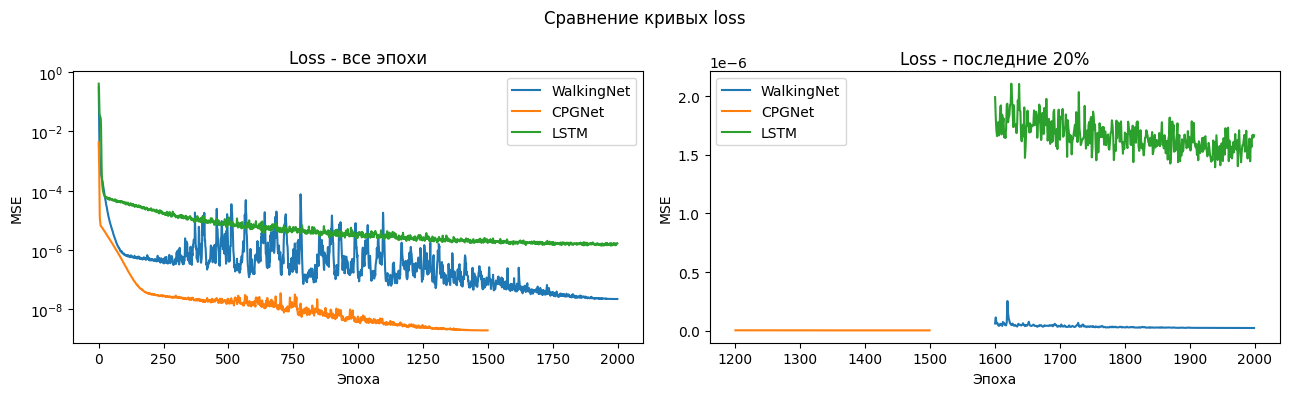

График сохранён в loss_comparison.png

Сустав                                        WalkingNet        CPGNet          LSTM
------------------------------------------------------------------------------------
Revolute_Head_Spine_1                           0.0000        0.0000        0.0001  
Revolute_Spine_1_2                              0.0001        0.0000        0.0001  
Revolute_Spine_2_3                              0.0000        0.0000        0.0002  
Revolute_Spine_3_4                              0.0000        0.0000        0.0001  
Revolute_Spine_4_LHip                           0.0002        0.0000        0.0002  
Revolute_LH_LBL                                 0.0001        0.0000        0.0002  
Revolute_Spine_4_RHip                           0.0001        0.0000        0.0002  
Revolute_RH_RBL                                 0.0001        0.0000        0.0002  
Revolute_Spine_1_RForearm                       0.0001        0.0000        0.0002  
Revolute_RF_RFL           

In [11]:
def main():
    commands = {
        # Сбор данных
        'collect': walk_with_data_collection,
        'collect_lstm': walk_with_data_collection_lstm,
        # Обучение
        'train_wn': train_walkingnet,
        'train_lstm': train_lstm,
        'train_cpg': train_cpg,
        'train_all': train_all,
        # Ходьба
        'walk': walk,
        'walk_wn': walk_with_wn,
        'walk_lstm': walk_with_lstm,
        'walk_cpg': walk_with_cpg,
        # Анализ
        'compare': compare_models
    }

    print("\n" + "═" * 55)
    print("Доступные команды:")
    print("═" * 55)
    groups = [
        ("Сбор данных", ['collect', 'collect_lstm']),
        ("Обучение", ['train_wn', 'train_lstm', 'train_cpg', 'train_all']),
        ("Ходьба", ['walk', 'walk_wn', 'walk_lstm', 'walk_cpg']),
        ("Анализ", ['compare']),
        ("Выход", ['stop']),
    ]
    for group, cmds in groups:
        print(f"{group:14s}: {', '.join(cmds)}")
    print("═" * 55)

    while True:
        cmd = input("\nКоманда: ").strip().lower()
        if cmd == 'stop':
            break
        elif cmd in commands:
            commands[cmd]()
        else:
            print(f"Неизвестная команда: '{cmd}'")


if __name__ == '__main__':
    try:
        main()
    except KeyboardInterrupt:
        print("\nПрервано")
    finally:
        sim.stopSimulation()
        print("Симуляция остановлена")